# Dual Evaluation and Improvement Ideas

In [1]:
import json
import os
import sys
import pickle
import re
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from networks import DualNet, DualNetEndToEnd, PrimalNet, PrimalNetEndToEnd, DualClassificationNetEndToEnd
import torch
from gep_config_parser import parse_config


## Helper

In [106]:
def get_dual_output(json_path, dual_path, data, if_run_test = True):
    # if run_test = True, only eval test set
    # if not, eval whole

    args = json.load(open(json_path))
    if args["dual_classification"]:
        dual_net = DualClassificationNetEndToEnd(args, data=data)
    else:
        dual_net = DualNetEndToEnd(args, data=data)
    dual_net.load_state_dict(
        torch.load(dual_path, weights_only=True),
        strict=False
    )
    dual_net.eval()


    train_size = int(args["train"] * data.X.shape[0])
    valid_size = int(args["valid"] * data.X.shape[0])

    indices = torch.arange(data.X.shape[0])

    # Split the indices
    train_indices = indices[:train_size]
    valid_indices = indices[train_size:train_size+valid_size]
    test_indices = indices[train_size+valid_size:]
    len_test = len(test_indices)

    if if_run_test:
        X = data.X[test_indices]   
        mu_true  = data.opt_targets["mu_operational"][test_indices]
        lamb_true = data.opt_targets["lamb_operational"][test_indices]
        y_true = data.opt_targets["y_operational"][test_indices]
    else:
        X = data.X
        mu_true  = data.opt_targets["mu_operational"]
        lamb_true = data.opt_targets["lamb_operational"]
        y_true = data.opt_targets["y_operational"]
    with torch.no_grad():
        mu_pred, lamb_pred = dual_net(X)


    return mu_pred, lamb_pred, mu_true, lamb_true, dual_net, y_true

In [107]:
def print_dual_lamb_dist(data, lamb_true,  lamb_pred):
    ''' 

    '''
    n_n = data.num_n
    for node_idx in range(n_n):
        node_lambdas = lamb_true[:, node_idx]
        unique, counts = np.unique(node_lambdas, return_counts=True)
        print(f"\nNode {node_idx} class distribution:")
        for val, count in zip(unique, counts):
            print(f"  λ={val:.4f}: {count} ({100*count/len(node_lambdas):.1f}%)")

In [108]:
def plot_lambda_dist(data, dual_net, lamb_pred, lamb_true, title = "Predicted vs True λ Class Distribution per Node"):
    lamb_pred_np = lamb_pred.numpy()
    lamb_true_np = lamb_true.numpy()

    # Get class values from the model
    class_values = dual_net.classes.numpy()
    class_labels = [f"{v:.4f}" for v in class_values]

    fig, axes = plt.subplots(2, data.num_n, figsize=(5 * data.num_n, 10))

    # Big overall title
    fig.suptitle(title, fontsize=18, y=1.02)

    for node_idx in range(data.num_n):
        node_name = data.N[node_idx]

        # ── Predicted distribution ──
        pred_vals = lamb_pred_np[:, node_idx]
        pred_counts = [(np.abs(pred_vals - v) < 1e-6).sum() for v in class_values]

        ax = axes[0, node_idx]
        bars = ax.bar(class_labels, pred_counts, color='steelblue', alpha=0.8)
        ax.set_title(f"Node {node_idx} ({node_name})\nPredicted class distribution")
        ax.set_xlabel("Class (λ value)")
        ax.set_ylabel("Count")
        ax.tick_params(axis='x', rotation=45)

        total = len(pred_vals)
        for bar, count in zip(bars, pred_counts):
            if count > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f'{100 * count / total:.1f}%',
                    ha='center',
                    va='bottom',
                    fontsize=9
                )

        # ── True distribution ──
        true_vals = lamb_true_np[:, node_idx]
        true_counts = [(np.abs(true_vals - v) < 1e-6).sum() for v in class_values]

        ax2 = axes[1, node_idx]
        bars2 = ax2.bar(class_labels, true_counts, color='coral', alpha=0.8)
        ax2.set_title(f"Node {node_idx} ({node_name})\nTrue class distribution")
        ax2.set_xlabel("Class (λ value)")
        ax2.set_ylabel("Count")
        ax2.tick_params(axis='x', rotation=45)

        for bar, count in zip(bars2, true_counts):
            if count > 0:
                ax2.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f'{100 * count / total:.1f}%',
                    ha='center',
                    va='bottom',
                    fontsize=9
                )

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # leaves space for suptitle
    plt.savefig("class_distribution_per_node.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("\n── Class prediction summary ──")
    print(f"{'Node':<12} {'Class':<12} {'Pred %':<10} {'True %':<10}")
    print("-" * 54)
    for node_idx in range(data.num_n):
        node_name = data.N[node_idx]
        pred_vals = lamb_pred_np[:, node_idx]
        true_vals = lamb_true_np[:, node_idx]
        total = len(pred_vals)
        for v, label in zip(class_values, class_labels):
            pred_pct = 100 * (np.abs(pred_vals - v) < 1e-6).sum() / total
            true_pct = 100 * (np.abs(true_vals - v) < 1e-6).sum() / total
            if true_pct > 0.01 or pred_pct > 0.01:
                print(f"{node_name:<12} {label:<12} {pred_pct:<10.1f} {true_pct:<10.1f}")

In [109]:
import torch
import numpy as np
import pandas as pd

def compute_dual_opt_gap_percent(
    dual_model,
    data,
    X=None,
    mu_true=None,
    lamb_true=None,
    return_dataframe=False,
    eps=1e-12,
):
    """
    Compute dual optimality gap (%) for a dual model.

    Gap definition:
        gap_i (%) = (z_true_i - z_pred_i) / max(eps, |z_true_i|) * 100

    For a dual maximization problem, this should usually be >= 0
    if the predicted dual is feasible and worse than optimal.

    Args:
        dual_model: trained dual model
        data: dataset/problem object
        X: optional input tensor [N, xdim]. If None, use data.X
        mu_true: optional true dual mu tensor [N, nineq]
                 If None, use data.opt_targets["mu_operational"]
        lamb_true: optional true dual lambda tensor [N, neq]
                   If None, use data.opt_targets["lamb_operational"]
        return_dataframe: if True, also return a per-sample dataframe
        eps: numerical stabilizer

    Returns:
        results: dict with mean/median/std/max gap and objective stats
        df (optional): per-sample dataframe
    """
    dual_model.eval()

    if X is None:
        X = data.X
    if mu_true is None:
        mu_true = data.opt_targets["mu_operational"]
    if lamb_true is None:
        lamb_true = data.opt_targets["lamb_operational"]

    with torch.no_grad():
        mu_pred, lamb_pred = dual_model(X)

        # Predicted and true dual objective values
        dual_obj_pred = data.dual_obj_fn(X, mu_pred, lamb_pred).reshape(-1)
        dual_obj_true = data.dual_obj_fn(X, mu_true, lamb_true).reshape(-1)

        # Gap in %
        gap_pct = (dual_obj_true - dual_obj_pred) / torch.clamp(torch.abs(dual_obj_true), min=eps) * 100.0

    gap_np = gap_pct.detach().cpu().numpy()
    pred_np = dual_obj_pred.detach().cpu().numpy()
    true_np = dual_obj_true.detach().cpu().numpy()

    results = {
        "mean_dual_opt_gap_pct": float(np.mean(gap_np)),
        "median_dual_opt_gap_pct": float(np.median(gap_np)),
        "std_dual_opt_gap_pct": float(np.std(gap_np)),
        "max_dual_opt_gap_pct": float(np.max(gap_np)),
        "min_dual_opt_gap_pct": float(np.min(gap_np)),
        "mean_pred_dual_obj": float(np.mean(pred_np)),
        "mean_true_dual_obj": float(np.mean(true_np)),
    }

    if return_dataframe:
        df = pd.DataFrame({
            "dual_obj_true": true_np,
            "dual_obj_pred": pred_np,
            "dual_opt_gap_pct": gap_np,
        })
        return results, df

    return results

## Evaluation

In [110]:
import pickle
data_path = "data/ED_data/Constraint/3Loc/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvTrue.pkl" # COnstrainted
data_path = "data/ED_data/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"


data = pickle.load(open(data_path, 'rb'))

# Load trained dual net
from networks import DualClassificationNetEndToEnd
import json

base_path = "outputs/PDL/ED/3Nodes-FraBelGer"
# base_path = ""


# exp_path = "Constraint/learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-BaselineConst2" # baseline in Const Model

#exp_path = "Constraint/learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-ConstBaselineSeperateHead"
#exp_path = "Constraint/learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-SepearteHeadNormbyObj"
exp_path = "learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-BendersBaseline"
# json_path = os.path.join(base_path, exp_path, "repeat:0", "args.json")
# exp_path = "experiment-output/ch7/3nodes/dual_model"
# exp_path = "learn_primal:True_train:0.8_rho:0.5_rhomax:5000_alpha:10_L:10-BaselineSeperateHead"
json_path = os.path.join(base_path, exp_path, "args.json")
dual_path = os.path.join(base_path, exp_path, "repeat:0", "dual_weights.pth")

# dual_path = os.path.join(base_path, exp_path, "dual_weights.pth")

In [112]:
mu_pred, lamb_pred, mu_true, lamb_true, dual_net, y_true = get_dual_output(json_path, dual_path, data, if_run_test=True)
compute_dual_opt_gap_percent(dual_net,data)

{'mean_dual_opt_gap_pct': 4.843755165389647,
 'median_dual_opt_gap_pct': 0.0,
 'std_dual_opt_gap_pct': 107.13928906031748,
 'max_dual_opt_gap_pct': 11106.259831363162,
 'min_dual_opt_gap_pct': 0.0,
 'mean_pred_dual_obj': 30004.78389157768,
 'mean_true_dual_obj': 30118.750282529934}

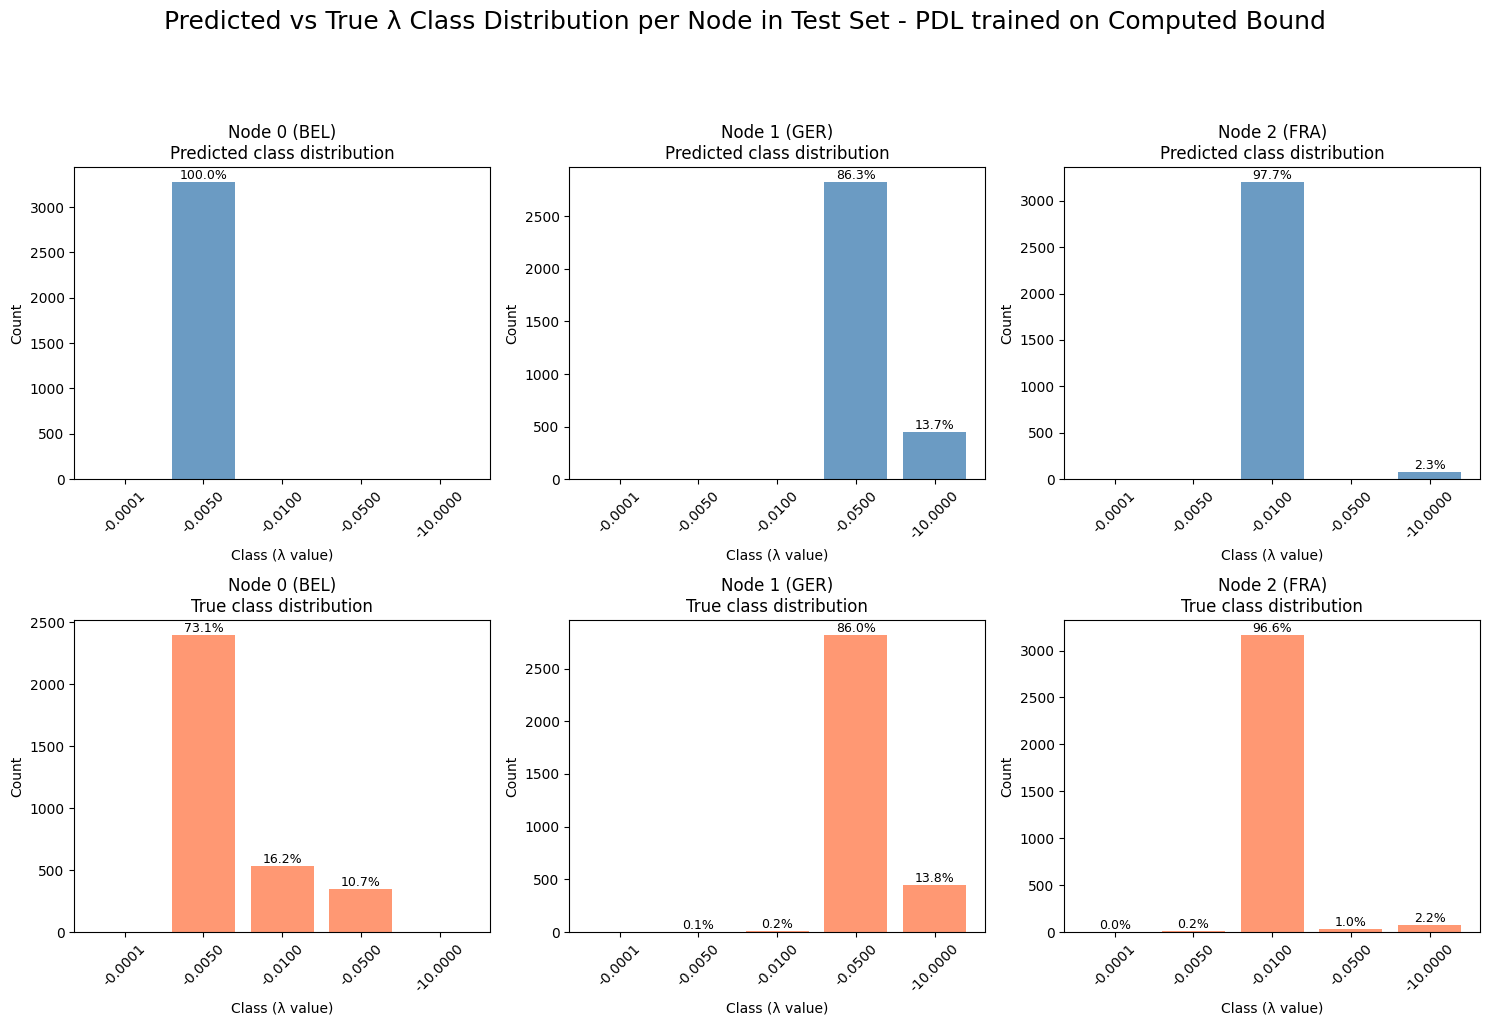


── Class prediction summary ──
Node         Class        Pred %     True %    
------------------------------------------------------
BEL          -0.0050      100.0      73.1      
BEL          -0.0100      0.0        16.2      
BEL          -0.0500      0.0        10.7      
GER          -0.0050      0.0        0.1       
GER          -0.0100      0.0        0.2       
GER          -0.0500      86.3       86.0      
GER          -10.0000     13.7       13.8      
FRA          -0.0001      0.0        0.0       
FRA          -0.0050      0.0        0.2       
FRA          -0.0100      97.7       96.6      
FRA          -0.0500      0.0        1.0       
FRA          -10.0000     2.3        2.2       


In [113]:

plot_lambda_dist(data, dual_net, lamb_pred, lamb_true, title = "Predicted vs True λ Class Distribution per Node in Test Set - PDL trained on Computed Bound")

## Dual Model Architecture Eval

In [114]:
print(dual_net.classes)

tensor([-1.0000e-04, -5.0000e-03, -1.0000e-02, -5.0000e-02, -1.0000e+01])


In [115]:
import numpy as np
import pandas as pd
import torch

def build_dual_eval_table(data, lamb_pred, lamb_true, y_true=None):
    """
    Create a dataframe with per-sample predicted/true lambda regime info.

    Args:
        data: problem data object
        lamb_pred: [N, num_n]
        lamb_true: [N, num_n]
        y_true: optional primal optimal solution [N, ydim]
                if given, we compute true primal objective from it

    Returns:
        df: pandas DataFrame
    """
    lamb_pred_np = lamb_pred.detach().cpu().numpy()
    lamb_true_np = lamb_true.detach().cpu().numpy()

    df = pd.DataFrame()

    # Per-node predicted / true lambda
    for i, node in enumerate(data.N):
        df[f"pred_{node}"] = lamb_pred_np[:, i]
        df[f"true_{node}"] = lamb_true_np[:, i]

    # Count how many scarcity nodes (-10)
    df["pred_num_scarcity"] = np.sum(np.isclose(lamb_pred_np, -10.0), axis=1)
    df["true_num_scarcity"] = np.sum(np.isclose(lamb_true_np, -10.0), axis=1)

    # Full regime tuple
    df["pred_tuple"] = [tuple(row) for row in lamb_pred_np]
    df["true_tuple"] = [tuple(row) for row in lamb_true_np]

    # Non-scarcity-only tuple (only meaningful when pred_num_scarcity == 0)
    df["pred_tuple_noscarcity"] = [
        tuple(row) if np.sum(np.isclose(row, -10.0)) == 0 else None
        for row in lamb_pred_np
    ]
    df["true_tuple_noscarcity"] = [
        tuple(row) if np.sum(np.isclose(row, -10.0)) == 0 else None
        for row in lamb_true_np
    ]

    if y_true is not None:
        X = data.X[:len(df)]
        true_obj = data.obj_fn(X, y_true).detach().cpu().numpy().reshape(-1)
        df["true_obj"] = true_obj

    return df

def summarize_by_predicted_scarcity(df):
    cols = ["pred_num_scarcity", "true_num_scarcity"]
    if "true_obj" in df.columns:
        cols.append("true_obj")

    summary = (
        df.groupby("pred_num_scarcity")
          .agg(
              count=("pred_num_scarcity", "size"),
              avg_true_num_scarcity=("true_num_scarcity", "mean"),
              std_true_num_scarcity=("true_num_scarcity", "std"),
              avg_true_obj=("true_obj", "mean") if "true_obj" in df.columns else ("true_num_scarcity", "mean"),
              std_true_obj=("true_obj", "std") if "true_obj" in df.columns else ("true_num_scarcity", "std"),
          )
          .reset_index()
          .sort_values("pred_num_scarcity")
    )

    summary["pct"] = 100 * summary["count"] / summary["count"].sum()
    return summary

In [116]:
# y_true = data.opt_targets["y_operational"][test_indi]
df = build_dual_eval_table(data, lamb_pred, lamb_true, y_true=y_true)
scarcity_summary = summarize_by_predicted_scarcity(df)
scarcity_summary

,pred_num_scarcity,count,avg_true_num_scarcity,std_true_num_scarcity,avg_true_obj,std_true_obj,pct
0,0,2765,0.004340,0.065747,2050.339441,1159.146352,84.350214
1,1,502,0.974104,0.171079,173311.092600,122834.574851,15.314216
2,2,11,1.909091,0.301511,311404.083318,225985.417574,0.335570


In [117]:
def summarize_by_predicted_tuple(df, min_count=20):
    grouped = (
        df.groupby("pred_tuple")
          .agg(
              count=("pred_tuple", "size"),
              avg_true_num_scarcity=("true_num_scarcity", "mean"),
              avg_true_obj=("true_obj", "mean") if "true_obj" in df.columns else ("true_num_scarcity", "mean"),
              std_true_obj=("true_obj", "std") if "true_obj" in df.columns else ("true_num_scarcity", "std"),
          )
          .reset_index()
          .sort_values(["count", "avg_true_obj"], ascending=[False, False])
    )

    grouped["pct"] = 100 * grouped["count"] / grouped["count"].sum()
    return grouped[grouped["count"] >= min_count]

tuple_summary = summarize_by_predicted_tuple(df, min_count=10)
print(f"tuple summary has {len(tuple_summary)} unique predicted regimes with at least 10 samples each")
tuple_summary

tuple summary has 4 unique predicted regimes with at least 10 samples each


,pred_tuple,count,avg_true_num_scarcity,avg_true_obj,std_true_obj,pct
3,"(-0.005, -0.05, -0.01)",2765,0.004340,2050.339441,1159.146352,84.350214
1,"(-0.005, -10.0, -0.01)",439,0.979499,174993.706246,122761.202198,13.392312
2,"(-0.005, -0.05, -10.0)",63,0.936508,161586.213385,123690.173106,1.921904
0,"(-0.005, -10.0, -10.0)",11,1.909091,311404.083318,225985.417574,0.335570


In [118]:
def summarize_noscarcity_patterns(df, min_count=20):
    sub = df[df["pred_num_scarcity"] == 0].copy()

    grouped = (
        sub.groupby("pred_tuple_noscarcity")
           .agg(
               count=("pred_tuple_noscarcity", "size"),
               avg_true_obj=("true_obj", "mean"),
               std_true_obj=("true_obj", "std"),
               avg_true_num_scarcity=("true_num_scarcity", "mean"),
           )
           .reset_index()
           .sort_values(["count", "avg_true_obj"], ascending=[False, False])
    )

    grouped["pct_within_no_scarcity"] = 100 * grouped["count"] / grouped["count"].sum()
    return grouped[grouped["count"] >= min_count]

In [119]:
noscarcity_summary = summarize_noscarcity_patterns(df, min_count=1)
noscarcity_summary

,pred_tuple_noscarcity,count,avg_true_obj,std_true_obj,avg_true_num_scarcity,pct_within_no_scarcity
0,"(-0.005, -0.05, -0.01)",2765,2050.339441,1159.146352,0.00434,100.0


In [120]:
import numpy as np
import pandas as pd

def summarize_dual_error_by_true_scarcity(data, lamb_pred, lamb_true, y_true=None):
    lamb_pred_np = lamb_pred.detach().cpu().numpy()
    lamb_true_np = lamb_true.detach().cpu().numpy()

    df = pd.DataFrame({
        "true_num_scarcity": np.sum(np.isclose(lamb_true_np, -10.0), axis=1),
        "pred_num_scarcity": np.sum(np.isclose(lamb_pred_np, -10.0), axis=1),
        "tuple_exact_match": np.all(np.isclose(lamb_pred_np, lamb_true_np), axis=1).astype(float),
        "node_acc": np.mean(np.isclose(lamb_pred_np, lamb_true_np), axis=1),
        "avg_abs_lambda_err": np.mean(np.abs(lamb_pred_np - lamb_true_np), axis=1),
        "scarcity_count_match": (
            np.sum(np.isclose(lamb_true_np, -10.0), axis=1) ==
            np.sum(np.isclose(lamb_pred_np, -10.0), axis=1)
        ).astype(float)
    })

    if y_true is not None:
        X = data.X[:len(df)]
        df["true_obj"] = data.obj_fn(X, y_true).detach().cpu().numpy().reshape(-1)

    summary = (
        df.groupby("true_num_scarcity")
          .agg(
              count=("true_num_scarcity", "size"),
              avg_true_obj=("true_obj", "mean") if "true_obj" in df.columns else ("node_acc", "mean"),
              tuple_exact_acc=("tuple_exact_match", "mean"),
              avg_node_acc=("node_acc", "mean"),
              avg_abs_lambda_err=("avg_abs_lambda_err", "mean"),
              scarcity_count_acc=("scarcity_count_match", "mean"),
          )
          .reset_index()
          .sort_values("true_num_scarcity")
    )

    if "count" in summary.columns:
        summary["pct"] = 100 * summary["count"] / summary["count"].sum()

    return summary

In [144]:
y_true = data.opt_targets["y_operational"]
error_by_true_regime = summarize_dual_error_by_true_scarcity(
    data, lamb_pred, lamb_true, y_true=y_true
)
error_by_true_regime

ValueError: Length of values (32768) does not match length of index (3278)

In [153]:
import itertools
import numpy as np
import pandas as pd
import torch


def evaluate_all_lambda_combinations_for_instance(
    data,
    dual_net,
    instance_idx,
    lambda_classes,
    num_lambda_dims=None,
    dual_obj_fn=None,
    device=None,
):
    if dual_obj_fn is None:
        raise ValueError("Please pass dual_obj_fn=... to evaluate the dual objective.")

    if isinstance(lambda_classes, torch.Tensor):
        classes = lambda_classes.detach().cpu().tolist()
    else:
        classes = list(lambda_classes)

    if num_lambda_dims is None:
        if hasattr(data, "N"):
            num_lambda_dims = len(data.N)
        else:
            raise ValueError("num_lambda_dims is None and data.N does not exist.")

    if device is None:
        device = data.X.device if isinstance(data.X, torch.Tensor) else torch.device("cpu")

    # Match dtype with tensors used inside complete_duals
    dtype = data.eq_cm.dtype

    # All class combinations: e.g. 5^3 = 125
    all_combos = list(itertools.product(classes, repeat=num_lambda_dims))

    lambda_tensor = torch.tensor(all_combos, dtype=dtype, device=device)

    # Repeat the chosen instance so each lambda combo is evaluated on same instance
    X_single = data.X[instance_idx].unsqueeze(0).repeat(len(all_combos), 1).to(device=device)

    # Optional: force same dtype too
    X_single = X_single.to(dtype=data.X.dtype)

    with torch.no_grad():
        mu_tensor = dual_net.complete_duals(lambda_tensor)
        obj_tensor = dual_obj_fn(X_single, mu_tensor, lambda_tensor).reshape(-1)

    df = pd.DataFrame(all_combos, columns=[f"lambda_{i}" for i in range(num_lambda_dims)])
    df["dual_obj"] = obj_tensor.detach().cpu().numpy()

    df = df.sort_values("dual_obj", ascending=False).reset_index(drop=True)
    df["rank"] = np.arange(1, len(df) + 1)

    mu_target = data.opt_targets['mu_operational'][instance_idx]
    lamb_target = data.opt_targets['lamb_operational'][instance_idx]

    opt_obj_target = dual_obj_fn(
        data.X[instance_idx].unsqueeze(0).to(device=device),
        mu_target.unsqueeze(0).to(device=device),
        lamb_target.unsqueeze(0).to(device=device)
    ).item()
    # print(f"Y optimal objective is: ")
    # print(opt_obj_target)
    return df, lambda_tensor, mu_tensor, obj_tensor

In [154]:
df_all, lambda_all, mu_all,obj_all = evaluate_all_lambda_combinations_for_instance(
    data=data,
    dual_net = dual_net,
    instance_idx=0,
    lambda_classes=dual_net.classes,
    num_lambda_dims=3,
    dual_obj_fn=data.dual_obj_fn,   # or your actual dual objective function
)

print(df_all.head(10))
# print(obj_all[0:5])


   lambda_0  lambda_1  lambda_2     dual_obj  rank
0   -0.0050     -0.05   -0.0100  1679.987868     1
1   -0.0001     -0.05   -0.0100  1632.079724     2
2   -0.0100     -0.05   -0.0100  1606.027610     3
3   -0.0050     -0.05   -0.0050  1562.466285     4
4   -0.0001     -0.05   -0.0050  1514.558141     5
5   -0.0100     -0.05   -0.0050  1453.006027     6
6   -0.0050     -0.05   -0.0001  1412.505134     7
7   -0.0001     -0.05   -0.0001  1399.386989     8
8   -0.0100     -0.05   -0.0001  1303.044875     9
9   -0.0500     -0.05   -0.0100   730.345544    10


In [155]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter


def human_format(x, pos):
    return f"{x:,.0f}"


def plot_all_lambda_objectives_clean(df_all, title_prefix="Instance level"):
    df_plot = df_all.sort_values("dual_obj", ascending=False).reset_index(drop=True).copy()
    x = np.arange(len(df_plot))
    y = df_plot["dual_obj"].values
    gaps = y[:-1] - y[1:]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # 1) Sorted objective as step plot
    axes[0].step(x, y, where="mid")
    axes[0].scatter(x, y, s=18)
    axes[0].set_title(f"{title_prefix}\nSorted dual objective")
    axes[0].set_xlabel("Instance (order by size of dual obj)")
    axes[0].set_ylabel("Dual objective")
    axes[0].grid(True, alpha=0.3)
    axes[0].ticklabel_format(style="plain", axis="y", useOffset=False)
    axes[0].yaxis.set_major_formatter(FuncFormatter(human_format))

    # 2) Adjacent drops
    axes[1].bar(np.arange(len(gaps)), gaps)
    axes[1].set_title(f"{title_prefix}\nDrop to next rank")
    axes[1].set_xlabel("Instance (order by size of dual obj)")
    axes[1].set_ylabel("Objective drop")
    axes[1].grid(True, alpha=0.3)
    axes[1].ticklabel_format(style="plain", axis="y", useOffset=False)
    axes[1].yaxis.set_major_formatter(FuncFormatter(human_format))

    # 3) Histogram
    axes[2].hist(y, bins=min(15, len(y)))
    axes[2].set_title(f"{title_prefix}\nHistogram")
    axes[2].set_xlabel("Dual objective")
    axes[2].set_ylabel("Count")
    axes[2].grid(True, alpha=0.3)
    axes[2].ticklabel_format(style="plain", axis="x", useOffset=False)
    axes[2].xaxis.set_major_formatter(FuncFormatter(human_format))

    plt.tight_layout()
    plt.show()

    return df_plot

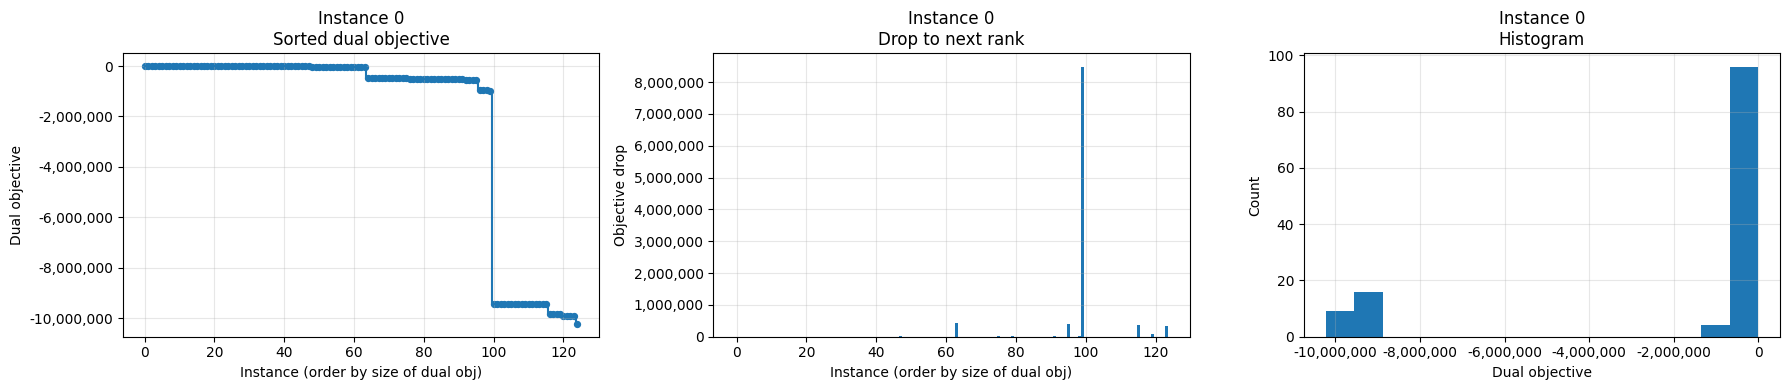

In [156]:
df_plot = plot_all_lambda_objectives_clean(df_all, title_prefix="Instance 0")

In [157]:
def summarize_by_num_minus10(df_all, scarcity_value=-10.0):
    df = df_all.copy()
    lambda_cols = [c for c in df.columns if c.startswith("lambda_")]

    df["num_minus10"] = sum(np.isclose(df[c], scarcity_value) for c in lambda_cols)

    summary = (
        df.groupby("num_minus10")["dual_obj"]
          .agg(["count", "mean", "std", "min", "max"])
          .reset_index()
          .sort_values("num_minus10")
    )
    return df, summary

In [158]:
df_with_groups, summary_minus10 = summarize_by_num_minus10(df_all, scarcity_value=-10.0)
print(summary_minus10)

   num_minus10  count          mean           std           min           max
0            0     64 -9.125151e+03  1.642815e+04 -3.858190e+04  1.679988e+03
1            1     48 -3.487666e+06  4.268833e+06 -9.462646e+06 -4.653179e+05
2            2     12 -6.894859e+06  4.391601e+06 -9.908699e+06 -9.393844e+05
3            3      1 -1.023070e+07           NaN -1.023070e+07 -1.023070e+07


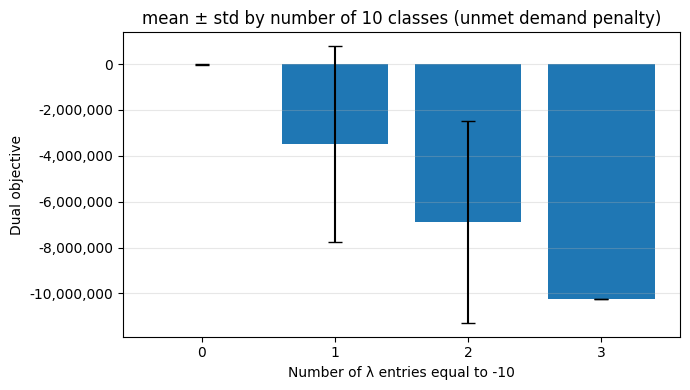

In [159]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

def human_format(x, pos):
    return f"{x:,.0f}"

def plot_mean_std_by_num_minus10(summary_df, title="Dual objective by number of -10 classes"):
    x = summary_df["num_minus10"].values
    mean = summary_df["mean"].values
    std = summary_df["std"].fillna(0).values

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x, mean, yerr=std, capsize=5)
    ax.set_title(title)
    ax.set_xlabel("Number of λ entries equal to -10")
    ax.set_ylabel("Dual objective")
    ax.set_xticks(x)
    ax.grid(True, axis="y", alpha=0.3)
    ax.ticklabel_format(style="plain", axis="y", useOffset=False)
    ax.yaxis.set_major_formatter(FuncFormatter(human_format))
    plt.tight_layout()
    plt.show()

plot_mean_std_by_num_minus10(summary_minus10, title="mean ± std by number of 10 classes (unmet demand penalty)")

/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_10631/35633233.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=True)


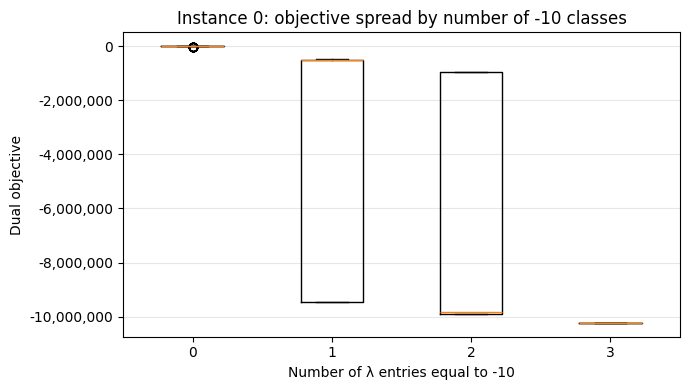

In [160]:
def plot_box_by_num_minus10(df_with_groups, title="Dual objective grouped by number of -10 classes"):
    groups = []
    labels = []
    for k in sorted(df_with_groups["num_minus10"].unique()):
        groups.append(df_with_groups.loc[df_with_groups["num_minus10"] == k, "dual_obj"].values)
        labels.append(str(k))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.boxplot(groups, labels=labels, showfliers=True)
    ax.set_title(title)
    ax.set_xlabel("Number of λ entries equal to -10")
    ax.set_ylabel("Dual objective")
    ax.grid(True, axis="y", alpha=0.3)
    ax.ticklabel_format(style="plain", axis="y", useOffset=False)
    ax.yaxis.set_major_formatter(FuncFormatter(human_format))
    plt.tight_layout()
    plt.show()

plot_box_by_num_minus10(df_with_groups, title="Instance 0: objective spread by number of -10 classes")

In [161]:
def collect_minus10_summary_across_instances(
    data,
    dual_net,
    lambda_classes,
    instance_indices,
    num_lambda_dims=3,
    dual_obj_fn=None,
    scarcity_value=-10.0,
):
    rows = []

    for idx in instance_indices:
        df_all, lambda_all, mu_all, obj_all = evaluate_all_lambda_combinations_for_instance(
            data=data,
            dual_net=dual_net,
            instance_idx=idx,
            lambda_classes=lambda_classes,
            num_lambda_dims=num_lambda_dims,
            dual_obj_fn=dual_obj_fn,
        )

        lambda_cols = [c for c in df_all.columns if c.startswith("lambda_")]
        df_all["num_minus10"] = sum(np.isclose(df_all[c], scarcity_value) for c in lambda_cols)
        df_all["instance_idx"] = idx

        rows.append(df_all[["instance_idx", "dual_obj", "num_minus10"]])

    out = pd.concat(rows, ignore_index=True)
    return out

In [166]:
all_grouped = collect_minus10_summary_across_instances(
    data=data,
    dual_net=dual_net,
    lambda_classes=dual_net.classes,
    instance_indices=range(20),   # example
    num_lambda_dims=3,
    dual_obj_fn=data.dual_obj_fn,
    scarcity_value=float(dual_net.classes.min()),
)

   num_minus10  count          mean           std           min           max
0            0   1280 -5.107935e+03  1.150368e+04 -3.858829e+04  4.769412e+03
1            1    960 -2.725049e+06  2.812514e+06 -9.662793e+06  3.045890e+05
2            2    240 -5.373643e+06  3.452529e+06 -1.150791e+07  4.867902e+05
3            3     20 -7.950889e+06  3.572078e+06 -1.254328e+07 -1.555644e+06


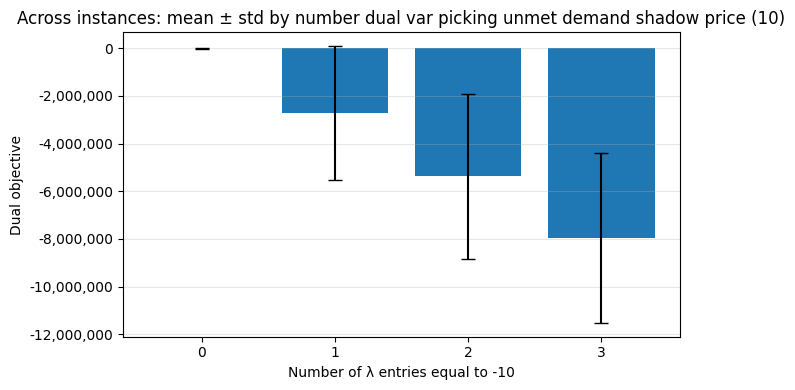

In [168]:
agg_summary = (
    all_grouped.groupby("num_minus10")["dual_obj"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
    .sort_values("num_minus10")
)

print(agg_summary)
plot_mean_std_by_num_minus10(agg_summary, title="Across instances: mean ± std by number dual var picking unmet demand shadow price (10)")

In [172]:
for i in data.G:
    print(f"{i} cost: {data.pVarCost[i]}")
print(f"Unmet Demand penalty: 10")

('BEL', 'WindOff') cost: 0.005
('BEL', 'Gas') cost: 0.05
('GER', 'Gas') cost: 0.05
('GER', 'SunPV') cost: 0.0001
('FRA', 'Nuclear') cost: 0.01
('FRA', 'SunPV') cost: 0.0001
Unmet Demand penalty: 10
